In [1]:
import numpy as np

In [2]:
X = np.array([[1,3,5,7,9,13,20,20,21,24,26],[5,7,11,14,15,17,18,19,21,22,26]]) 

X has shape (m, n)
- m = number of data points (samples)
- n = number of features (dimensions)

Each row represents one data point
Each column represents one feature

In [3]:
print(X.shape) 

(2, 11)


NumPy standard: (m, n) → rows = samples, columns = features

In [4]:
X=X.T 

Transposing X to switch from (m, n) → (n, m)
Now:
- Each column represents one data point
- Each row represents one feature

This format is useful for vectorized math operations(e.g., linear algebra derivations, neural network formulas)

In [5]:
print(X.shape)

(11, 2)


In [6]:
print(X)

[[ 1  5]
 [ 3  7]
 [ 5 11]
 [ 7 14]
 [ 9 15]
 [13 17]
 [20 18]
 [20 19]
 [21 21]
 [24 22]
 [26 26]]


In [7]:
import matplotlib.pyplot as plt # for plotting 

<Figure size 640x480 with 0 Axes>

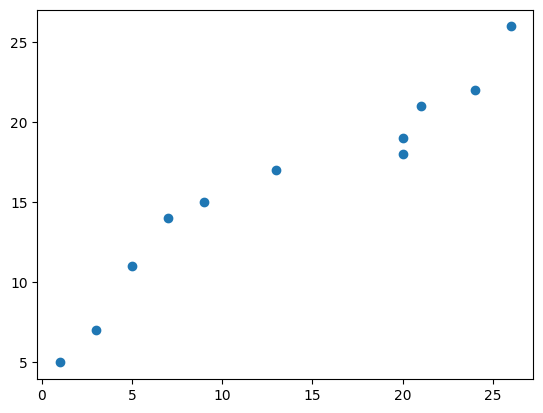

<Figure size 640x480 with 0 Axes>

In [8]:
plt.scatter(X[:,0],X[:,1]) # scatter plot b/w both values as X[:,0] as x-axis and X[:,1] as y-axis -> X[row_slice, column_slice] eachh slice follow[start : stop : step]
plt.figure()

In [9]:
X_mean = X - np.mean(X,axis=0)  # centering the data i.e., subracting men of each feature from idividual instace of the feature
print(X_mean)

[[-12.54545455 -10.90909091]
 [-10.54545455  -8.90909091]
 [ -8.54545455  -4.90909091]
 [ -6.54545455  -1.90909091]
 [ -4.54545455  -0.90909091]
 [ -0.54545455   1.09090909]
 [  6.45454545   2.09090909]
 [  6.45454545   3.09090909]
 [  7.45454545   5.09090909]
 [ 10.45454545   6.09090909]
 [ 12.45454545  10.09090909]]


<Figure size 640x480 with 0 Axes>

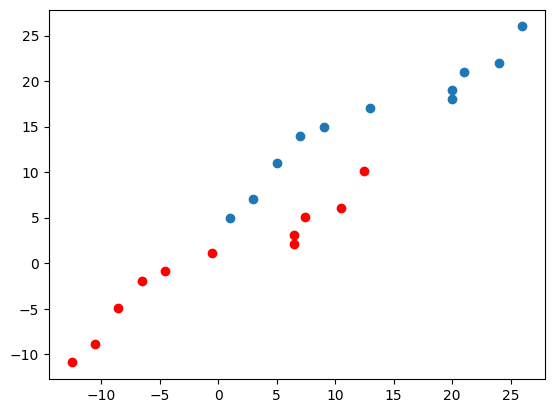

<Figure size 640x480 with 0 Axes>

In [10]:
plt.scatter(X_mean[:,0],X_mean[:,1],c=['red'])
plt.scatter(X[:,0],X[:,1])
plt.figure()

In [11]:
C = np.cov(X_mean,rowvar=False) 

In [12]:
print(C)

[[80.87272727 54.95454545]
 [54.95454545 40.69090909]]


In [13]:
eigen_vals,eigen_vecs = np.linalg.eig(C)
print(eigen_vals)
print(eigen_vecs)

[119.29375452   2.26988184]
[[ 0.81956216 -0.57299028]
 [ 0.57299028  0.81956216]]


In [14]:
sorted_eigen_indexes = np.argsort(eigen_vals,)[::-1] # since this will return ascending ordered list and we want greates values we reverse the list
# print(eigen_vals[sorted_eigen_indexes])
sorted_evals = eigen_vals[sorted_eigen_indexes]
sorted_evec=eigen_vecs[:,sorted_eigen_indexes]
print(sorted_evals)
print(sorted_evec)

[119.29375452   2.26988184]
[[ 0.81956216 -0.57299028]
 [ 0.57299028  0.81956216]]


## Projection

In [15]:
n = 1 
evec_subset = sorted_evec[:,0:n] #all rows for top n values i.,e top k eigen vectors
print(evec_subset)

[[0.81956216]
 [0.57299028]]


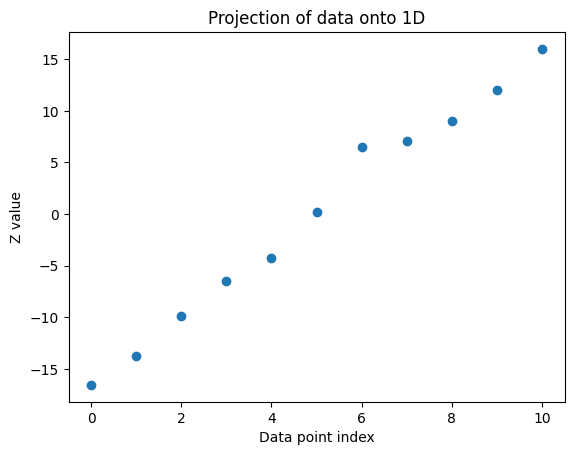

In [16]:
Z = np.dot(X_mean,evec_subset) # Z = XV^T
plt.scatter(range(len(Z)), Z)
plt.title("Projection of data onto 1D")
plt.xlabel("Data point index")
plt.ylabel("Z value")
plt.show()

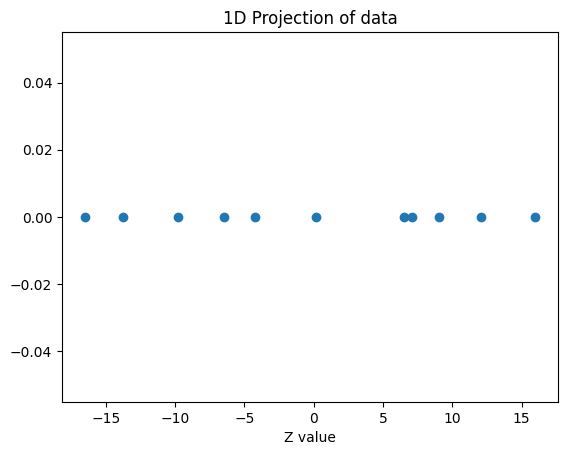

In [17]:
plt.scatter(Z, [0]*len(Z))
# plt.yticks([])  # hide y-axis
plt.title("1D Projection of data")
plt.xlabel("Z value")
plt.show()

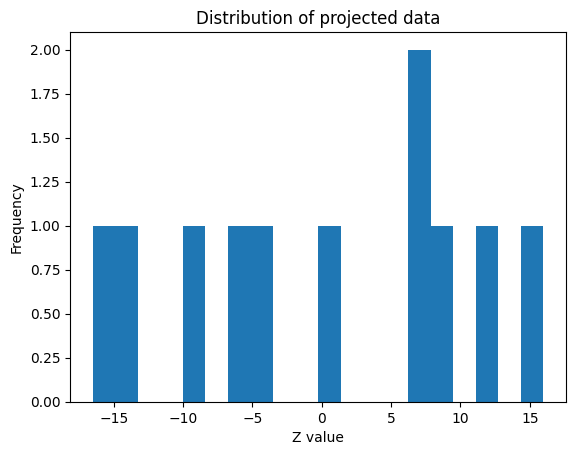

In [18]:
plt.hist(Z, bins=20)
plt.title("Distribution of projected data")
plt.xlabel("Z value")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Transformation
X_reduced = np.dot(Z,evec_subset.T)
print(X_reduced)

[[-13.54947944  -9.47300927]
 [-11.26691285  -7.87717125]
 [ -8.04514396  -5.62469751]
 [ -5.29297622  -3.70054164]
 [ -3.48001078  -2.43302147]
 [  0.14592009   0.10201885]
 [  5.31729623   3.71754478]
 [  5.78689739   4.04586264]
 [  7.39778183   5.1720995 ]
 [  9.88242941   6.90922082]
 [ 13.1041983    9.16169456]]


In [20]:
X_diff = X_mean - X_reduced
print(X_diff)

[[ 1.00402489 -1.43608164]
 [ 0.72145831 -1.03191966]
 [-0.50031059  0.71560661]
 [-1.25247833  1.79145073]
 [-1.06544376  1.52393056]
 [-0.69137463  0.98889024]
 [ 1.13724922 -1.62663569]
 [ 0.66764807 -0.95495354]
 [ 0.05676362 -0.08119041]
 [ 0.57211605 -0.81831173]
 [-0.64965285  0.92921453]]


In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
pca.fit(X_mean)
Xr=pca.transform(X_mean)
print(Xr)

[[-16.53258291]
 [-13.74747803]
 [ -9.81639259]
 [ -6.45829743]
 [ -4.24618282]
 [  0.17804639]
 [  6.48797183]
 [  7.0609621 ]
 [  9.02650482]
 [ 12.05818159]
 [ 15.98926703]]
